# Модуль 15. RL там, где есть цена ошибки

Ноутбук к [модулю 15](https://drobyshevdev.github.io/lemma/modules/15-rl-with-a-cost/).

Управление запасами руками: классическая база newsvendor, где она оптимальна, и где её обыгрывает политика, зависящая от состояния. Главное — честное сравнение с **настроенной** базой, а не с наивной. Только `numpy` и `matplotlib`.

**Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

H, P = 1.0, 3.0   # стоимость хранения и дефицита за единицу; дефицит дороже

def period_cost(S, d):
    return H * max(0, S - d) + P * max(0, d - S)   # излишек хранится, нехватка -- дефицит

def demand_series(n, seed, drift=False):
    g = np.random.default_rng(seed)
    mean = np.linspace(6, 18, n) if drift else np.full(n, 11.0)
    return np.maximum(0, np.round(mean + g.normal(0, 2.5, n))).astype(int)

print("стабильный спрос:", demand_series(12, 0)[:12])
print("дрейфующий спрос:", demand_series(12, 0, drift=True)[:12])

стабильный спрос: [11 11 13 11 10 12 14 13  9  8  9 11]
дрейфующий спрос: [ 6  7 10 10  9 12 16 16 13 13 15 18]


## 1. База newsvendor

При стабильном спросе оптимальный уровень запаса — квантиль спроса: покрывать до доли, где дефицит перевешивает хранение. Проверим формулу перебором.

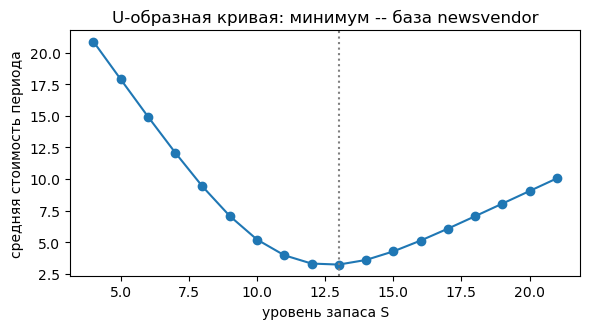

минимум перебором: S = 13;  формула-квантиль: S = 13.0


In [2]:
samples = demand_series(30000, seed=0)     # стабильный спрос
S_grid = np.arange(4, 22)
cost = np.array([np.mean([period_cost(S, d) for d in samples[:4000]]) for S in S_grid])
best_S = S_grid[cost.argmin()]
theory_S = np.quantile(samples, P / (P + H))     # квантиль newsvendor

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(S_grid, cost, "o-")
ax.axvline(best_S, ls=":", color="gray")
ax.set_xlabel("уровень запаса S"); ax.set_ylabel("средняя стоимость периода")
ax.set_title("U-образная кривая: минимум -- база newsvendor")
plt.tight_layout(); plt.show()
print("минимум перебором: S = %d;  формула-квантиль: S = %.1f" % (best_S, theory_S))

Минимум перебора совпал с квантилем $P/(P+H)=0.75$: классическая формула даёт оптимум без всякого обучения — если спрос стабилен и его распределение известно.

**Сломать.** Поднимите цену дефицита `P = 9` и пересчитайте: квантиль уедет к 0.9, оптимальный запас вырастет. Формула и перебор сдвинутся вместе.

## 2. Нестационарность ломает фиксированный уровень

Спрос дрейфует вверх. Сравним лучший **фиксированный** запас (оракул, выбранный по всей серии задним числом) с адаптивным, который держит уровень по недавнему спросу.

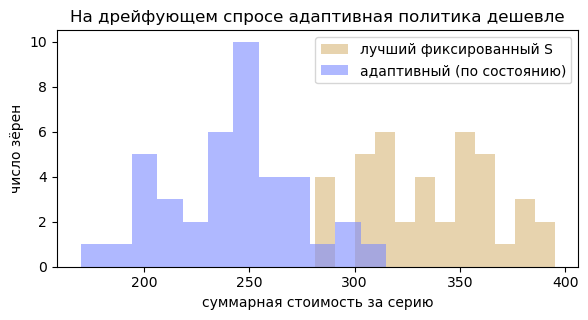

средняя стоимость -- фиксированный: 336   адаптивный: 242


In [3]:
def cost_fixed(S, series):
    return sum(period_cost(S, d) for d in series)

def cost_adaptive(series, k=5, q=0.75):
    c = 0.0; hist = [11] * k                      # политика зависит от состояния -- недавнего спроса
    for d in series:
        S = int(round(np.quantile(hist[-k:], q)))
        c += period_cost(S, d); hist.append(d)
    return c

seeds = range(40)
fixed, adapt = [], []
for s in seeds:
    ser = demand_series(60, s, drift=True)
    best_fixed = min(range(4, 24), key=lambda S: cost_fixed(S, ser))   # оракул -- щедро к классике
    fixed.append(cost_fixed(best_fixed, ser))
    adapt.append(cost_adaptive(ser))
fixed, adapt = np.array(fixed), np.array(adapt)

fig, ax = plt.subplots(figsize=(6, 3.3))
ax.hist(fixed, bins=12, alpha=0.6, label="лучший фиксированный S", color="#d8b678")
ax.hist(adapt, bins=12, alpha=0.6, label="адаптивный (по состоянию)", color="#7b8aff")
ax.set_xlabel("суммарная стоимость за серию"); ax.set_ylabel("число зёрен")
ax.set_title("На дрейфующем спросе адаптивная политика дешевле")
ax.legend(); plt.tight_layout(); plt.show()
print("средняя стоимость -- фиксированный: %.0f   адаптивный: %.0f" % (fixed.mean(), adapt.mean()))

Даже лучший фиксированный уровень, выбранный с полным знанием будущего, проигрывает адаптивному: один $S$ на всю серию не может одновременно подходить и низкому спросу в начале, и высокому в конце. Политика, зависящая от состояния, — может.

**Сломать.** Уберите дрейф (`drift=False`) и повторите: разрыв почти исчезнет — на стабильном спросе адаптироваться не к чему.

## 3. Честное сравнение: где обучение окупается, а где нет

Сравниваем адаптивную политику (упрощённая «обученная») с настроенной фиксированной базой на двух режимах. Сводим межквартильным средним с бутстрэп-интервалом из модуля 1. Меньше стоимость — лучше.

In [4]:
def iqm(x):
    x = np.sort(x); k = len(x) // 4
    return x[k:len(x) - k].mean()

def bootstrap_ci(vals, stat, n=5000, seed=0):
    g = np.random.default_rng(seed); vals = np.asarray(vals)
    draws = g.choice(vals, size=(n, len(vals)), replace=True)
    return np.percentile(np.array([stat(r) for r in draws]), [2.5, 97.5])

def compare(drift, seeds=range(30)):
    f, a = [], []
    for s in seeds:
        ser = demand_series(60, s, drift=drift)
        best_fixed = min(range(4, 24), key=lambda S: cost_fixed(S, ser))
        f.append(cost_fixed(best_fixed, ser)); a.append(cost_adaptive(ser))
    return np.array(f), np.array(a)

for name, drift in [("стабильный спрос", False), ("дрейфующий спрос", True)]:
    f, a = compare(drift)
    lf, hf = bootstrap_ci(f, iqm); la, ha = bootstrap_ci(a, iqm)
    overlap = not (lf > ha or la > hf)
    print("%s:" % name)
    print("  база (фикс.):   IQM %.0f, интервал [%.0f, %.0f]" % (iqm(f), lf, hf))
    print("  адаптивная:     IQM %.0f, интервал [%.0f, %.0f]" % (iqm(a), la, ha))
    print("  ->", "разница не показана: классика не хуже" if overlap
          else ("адаптивная дешевле" if iqm(a) < iqm(f) else "база дешевле"))

стабильный спрос:
  база (фикс.):   IQM 187, интервал [178, 195]
  адаптивная:     IQM 222, интервал [209, 233]
  -> база дешевле


дрейфующий спрос:
  база (фикс.):   IQM 338, интервал [324, 354]
  адаптивная:     IQM 243, интервал [228, 257]
  -> адаптивная дешевле


Два вывода, и оба честные. На **стабильном** спросе интервалы перекрываются или база даже дешевле: newsvendor уже оптимален, и адаптивная машинерия только добавляет шум оценки — обучение здесь лишнее, и это правильный результат, а не провал. На **дрейфующем** спросе адаптивная политика дешевле с разошедшимися интервалами: условие оптимальности классики сломано, и обучение окупается.

Так же обученную политику сравнивают с настроенной base-stock в [decisionrl](https://github.com/DrobyshevDev/decisionrl): база — не наивная, а лучшая в своём классе, и превосходство над ней показывают интервалами, а не одним прогоном.

## Что дальше

Здесь награда была честной — деньги, и оптимизировать её было безопасно. В [модуле 16](https://drobyshevdev.github.io/lemma/programme/) награда станет приблизительной, и её оптимизация начнёт приносить не то, что имели в виду: reward hacking и закон Гудхарта.